In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.eda import load_data, validate_data, get_categorical_and_numerical_features
from src.eda import get_minutes_stats, get_call_stats, get_charge_stats
from utils.eda import describe_stats
from src.visualization import plot_states, plot_call_minutes, plot_call_counts
from src.visualization import plot_charge_distributions, plot_correlation

In [2]:
df = load_data()
df

,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,KS,128,415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,SC,79,415,no,no,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2,False
2662,AZ,192,415,no,yes,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
2663,WV,68,415,no,no,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
2664,RI,28,510,no,no,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   state                   2666 non-null   category
 1   account_length          2666 non-null   int64   
 2   area_code               2666 non-null   category
 3   international_plan      2666 non-null   category
 4   voice_mail_plan         2666 non-null   category
 5   number_vmail_messages   2666 non-null   int64   
 6   total_day_minutes       2666 non-null   float64 
 7   total_day_calls         2666 non-null   int64   
 8   total_day_charge        2666 non-null   float64 
 9   total_eve_minutes       2666 non-null   float64 
 10  total_eve_calls         2666 non-null   int64   
 11  total_eve_charge        2666 non-null   float64 
 12  total_night_minutes     2666 non-null   float64 
 13  total_night_calls       2666 non-null   int64   
 14  total_night_charge      2666 non-nu

In [4]:
validate_data(df)

'Data is valid'

In [5]:
def null_values(df):
	n_nulls = df.isnull().sum().sum() # number of null values
	print(f"Dataset contains {n_nulls} null values.")

null_values(df)

Dataset contains 0 null values.


In [6]:
def get_duplicates(df):
	n_exact_dups = df.duplicated().sum() # duplicate rows
	print(f"Dataset contains {n_exact_dups} exact duplicates")

get_duplicates(df)

Dataset contains 0 exact duplicates


We are dealing with a imbalanced dataset, so we need to do some data understanding to understand the data better.

In [7]:
df['churn'].value_counts() # churn imbalance

churn
False    2278
True      388
Name: count, dtype: int64

In [8]:
categorical_features, numerical_features = get_categorical_and_numerical_features(df)

print(f"Categorical features: {categorical_features}")
print("--" * 50)
print(f"Numerical features: {numerical_features}")
print("--" * 50)
print(f"Number of categorical features: {len(categorical_features)}")
print(f"Number of numerical features: {len(numerical_features)}")

Categorical features: ['state', 'area_code', 'international_plan', 'voice_mail_plan', 'churn']
----------------------------------------------------------------------------------------------------
Numerical features: ['account_length', 'number_vmail_messages', 'total_day_minutes', 'total_day_calls', 'total_day_charge', 'total_eve_minutes', 'total_eve_calls', 'total_eve_charge', 'total_night_minutes', 'total_night_calls', 'total_night_charge', 'total_intl_minutes', 'total_intl_calls', 'total_intl_charge', 'customer_service_calls']
----------------------------------------------------------------------------------------------------
Number of categorical features: 5
Number of numerical features: 15


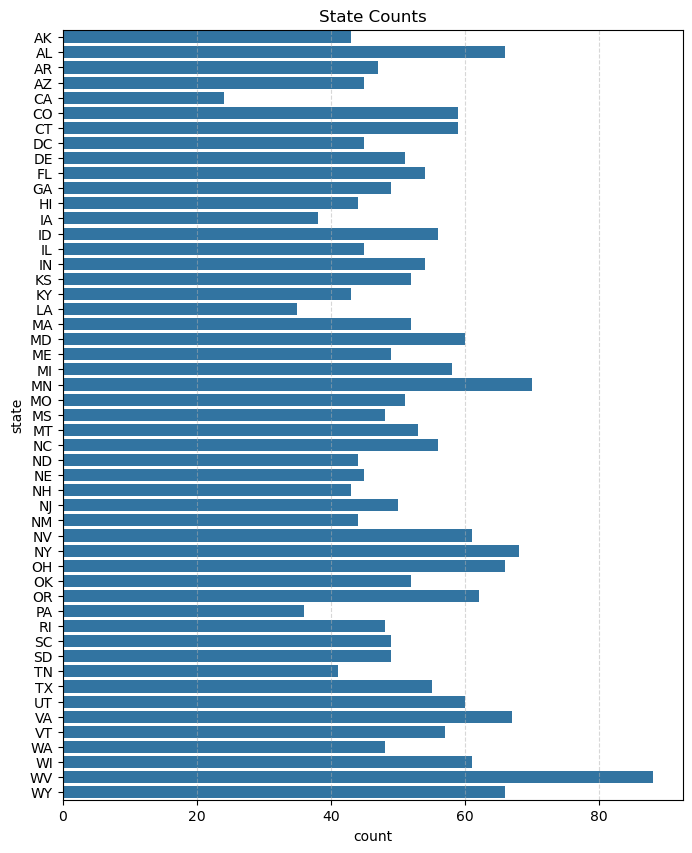

In [9]:
plot_states(df)

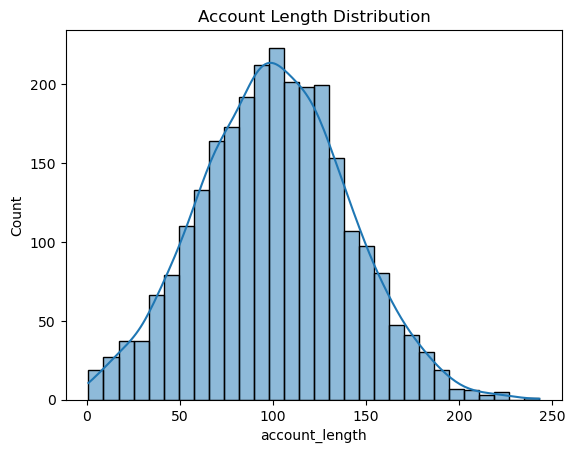

,Value
Statistic,
Count,"2,666.000"
Missing,0.000
Unique,205.000
Mean,100.620
Median,100.000
Std. Dev.,39.564
Variance,"1,565.308"
Min,1.000
Q1 (25%),73.000


In [10]:
sns.histplot(
    data=df,
    x="account_length",
    bins=30,
    kde=True,
)

plt.title("Account Length Distribution")
plt.show()

describe_stats(
    df=df,
    feature="account_length"
)

In [11]:
df['area_code'].value_counts() / df.shape[0] * 100

area_code
415    49.437359
510    25.468867
408    25.093773
Name: count, dtype: float64

In [12]:
df['international_plan'].value_counts() / df.shape[0] * 100

international_plan
no     89.872468
yes    10.127532
Name: count, dtype: float64

In [13]:
df['voice_mail_plan'].value_counts() / df.shape[0] * 100

voice_mail_plan
no     72.505626
yes    27.494374
Name: count, dtype: float64

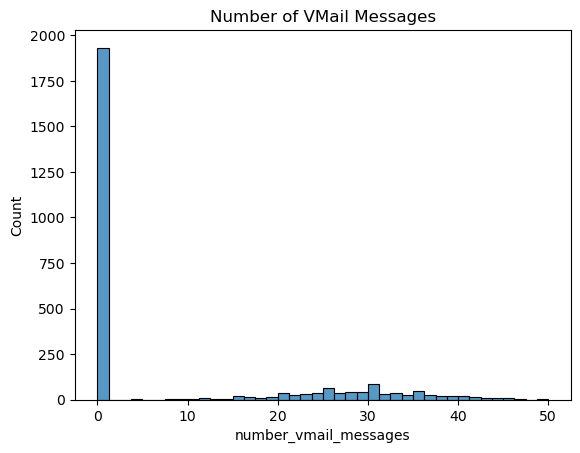

,Value
Statistic,
Count,"2,666.000"
Missing,0.000
Unique,42.000
Mean,8.022
Median,0.000
Std. Dev.,13.612
Variance,185.294
Min,0.000
Q1 (25%),0.000


In [14]:
sns.histplot(
    data=df,
    x="number_vmail_messages",
    bins=40,
)

plt.title("Number of VMail Messages")
plt.show()

describe_stats(
    df=df,
    feature="number_vmail_messages",
)

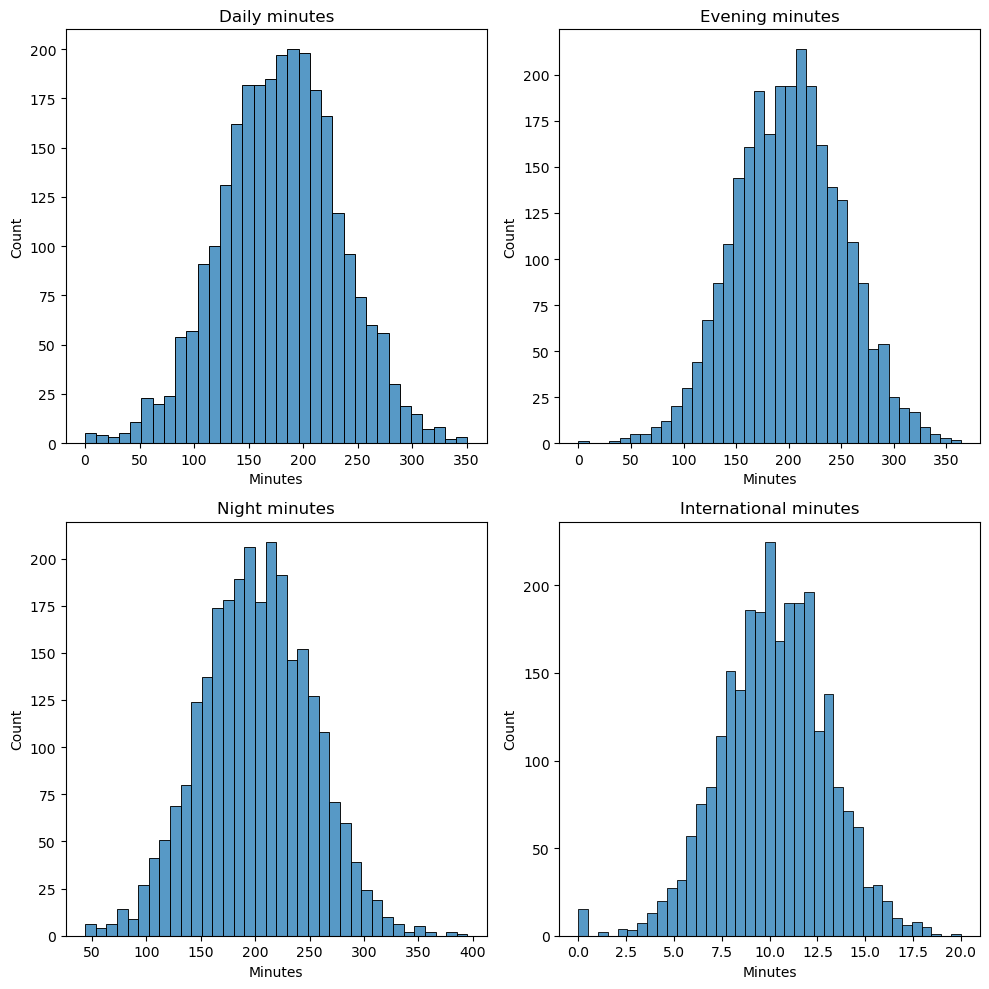

In [15]:
plot_call_minutes(df)

In [16]:
get_minutes_stats(df)

,total_day_minutes,total_eve_minutes,total_night_minutes,total_intl_minutes
Statistic,,,,
Count,"2,666.000","2,666.000","2,666.000","2,666.000"
Missing,0.000,0.000,0.000,0.000
Unique,"1,489.000","1,442.000","1,444.000",158.000
Mean,179.482,200.386,201.169,10.237
Median,179.950,200.900,201.150,10.200
Std. Dev.,54.210,50.952,50.780,2.788
Variance,"2,938.762","2,596.057","2,578.641",7.775
Min,0.000,0.000,43.700,0.000
Q1 (25%),143.400,165.300,166.925,8.500


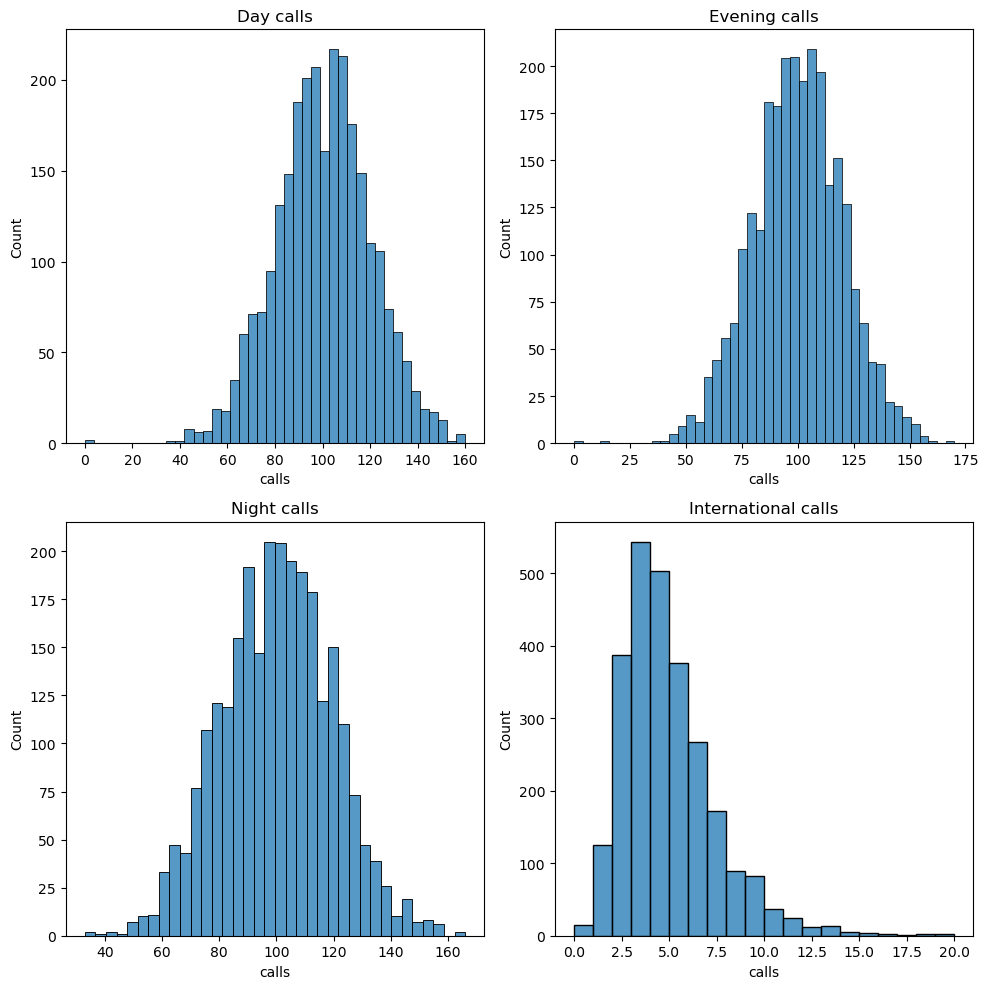

In [17]:
plot_call_counts(df)

In [18]:
get_call_stats(df)

,total_day_calls,total_eve_calls,total_night_calls,total_intl_calls
Statistic,,,,
Count,"2,666.000","2,666.000","2,666.000","2,666.000"
Missing,0.000,0.000,0.000,0.000
Unique,115.000,120.000,118.000,21.000
Mean,100.310,100.024,100.106,4.467
Median,101.000,100.000,100.000,4.000
Std. Dev.,19.988,20.161,19.418,2.456
Variance,399.527,406.484,377.077,6.033
Min,0.000,0.000,33.000,0.000
Q1 (25%),87.000,87.000,87.000,3.000


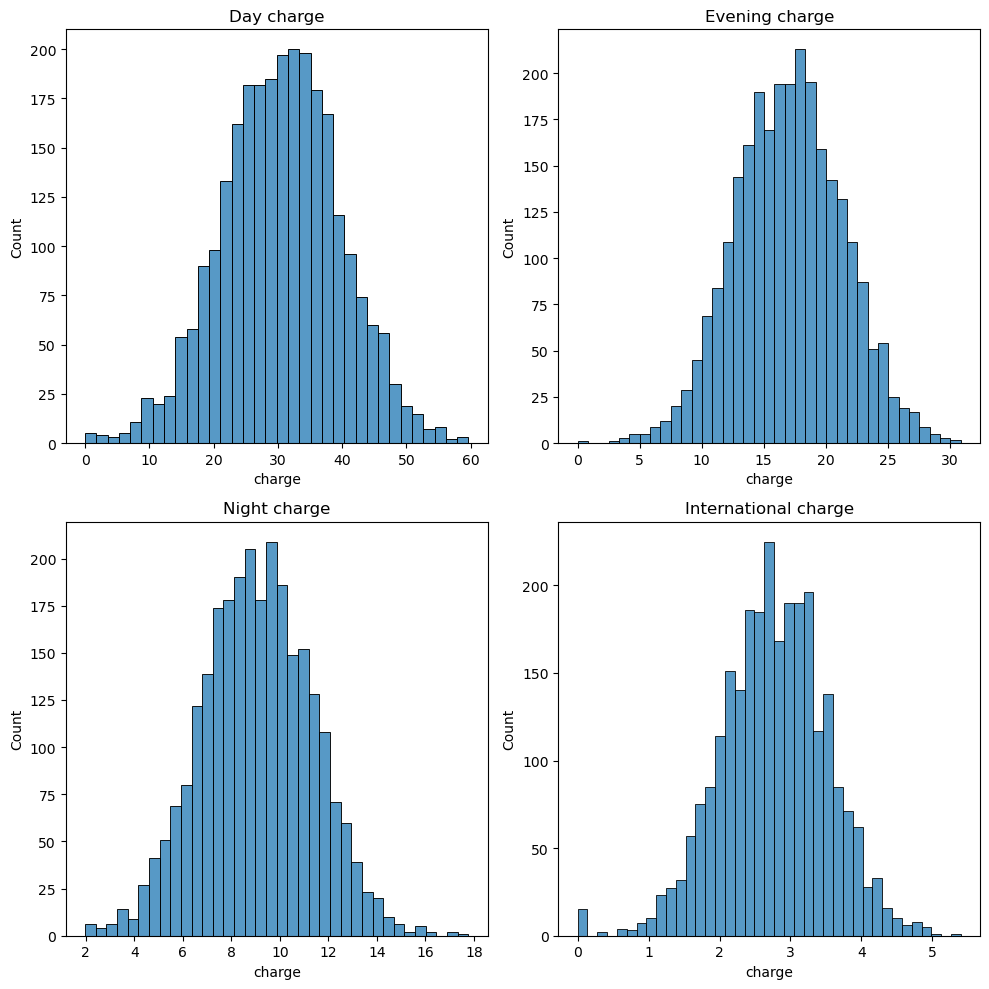

In [19]:
plot_charge_distributions(df)

In [20]:
get_charge_stats(df)

,total_day_charge,total_eve_charge,total_night_charge,total_intl_charge
Statistic,,,,
Count,"2,666.000","2,666.000","2,666.000","2,666.000"
Missing,0.000,0.000,0.000,0.000
Unique,"1,489.000","1,301.000",885.000,158.000
Mean,30.512,17.033,9.053,2.764
Median,30.590,17.080,9.050,2.750
Std. Dev.,9.216,4.331,2.285,0.753
Variance,84.930,18.756,5.222,0.567
Min,0.000,0.000,1.970,0.000
Q1 (25%),24.380,14.050,7.512,2.300


There is a pattern here that when our customer service calls are 0 to 3 calls there is a meaningfull and huge difference in churn rate and many of our customer do not churn, But by looking at the chart below we can see that after that (4 or more calls) about half of the 
customers churn.

**Null hypothesis:** If we have more than 4 calls to customer service then we will have a higher churn rate.

**Alternative hypothesis:** If we have more than 4 calls to customer service then we will have a lower churn rate.

**Business Insight:** Customer service calls are a good indicator of customer satisfaction. If we have more than 4 calls to customer service then we will have a higher churn rate.

**Business Insight:** We may have inefficient customer service that after a customer calls us for more than 4 times we couldn't resolve the issue and the customer churns.

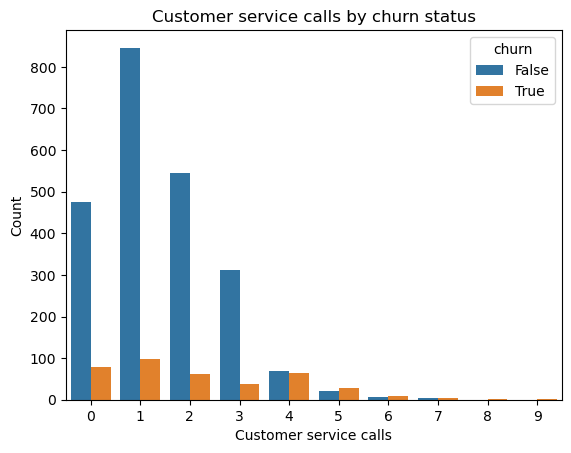

In [21]:
sns.countplot(
    data=df,
    x="customer_service_calls",
    hue="churn",
)

plt.title("Customer service calls by churn status")
plt.xlabel("Customer service calls")
plt.ylabel("Count")

plt.show()

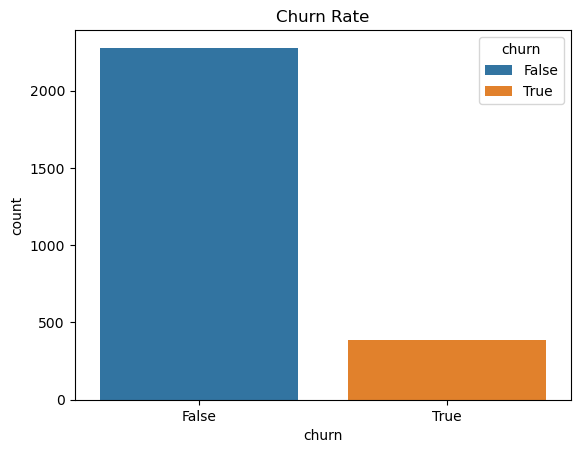

In [22]:
sns.countplot(
    data=df,
    x="churn",
    hue="churn",
)

plt.title("Churn Rate")
plt.show()

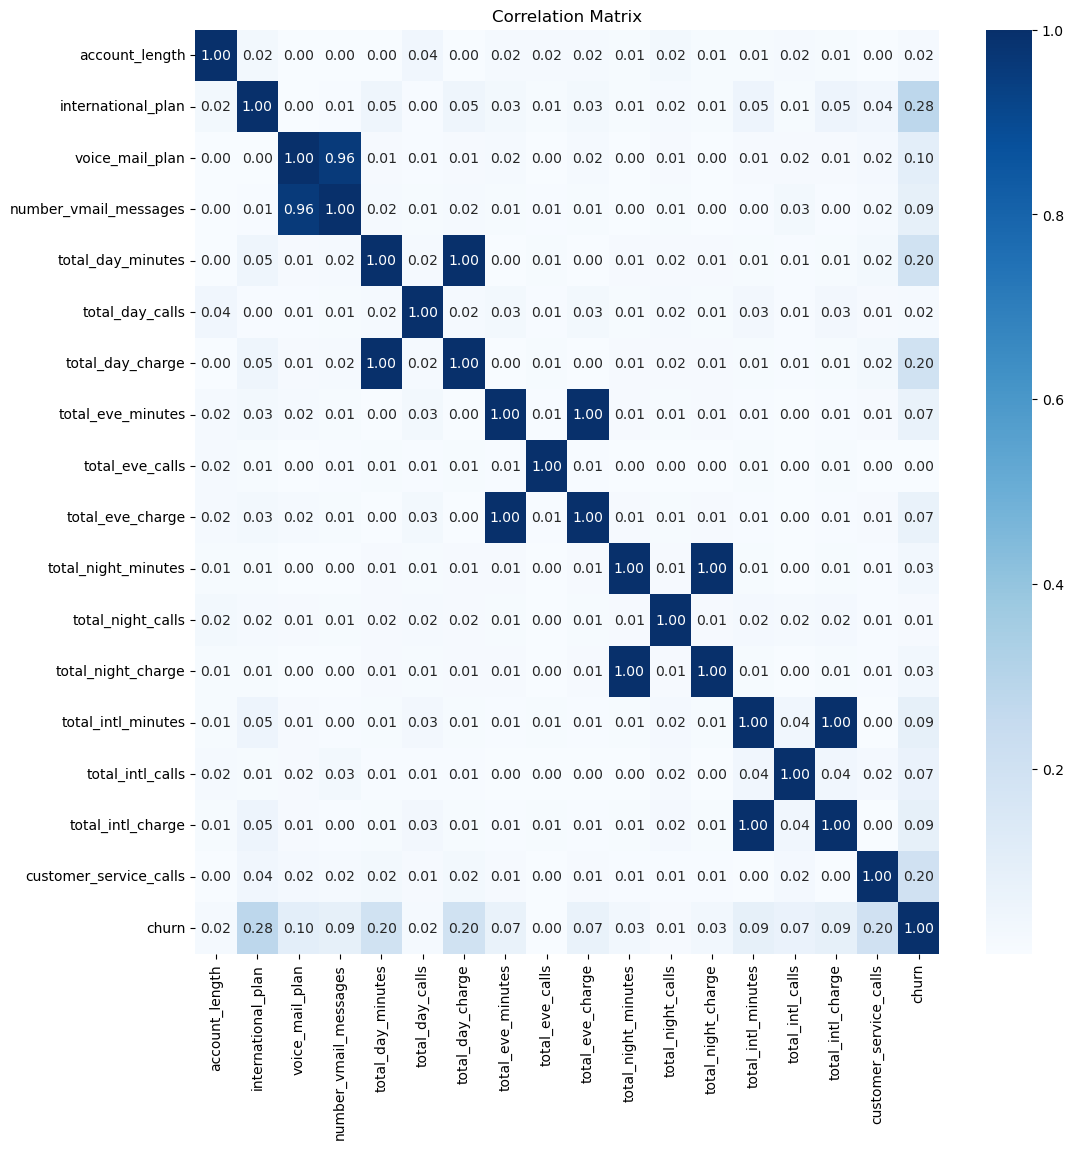

In [23]:
plot_correlation(df)

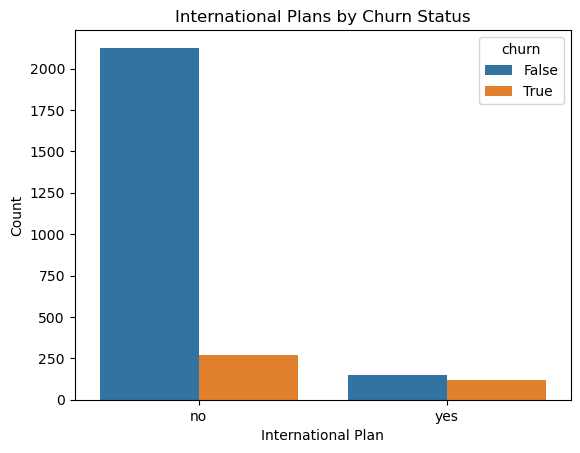

In [24]:
sns.countplot(
    data=df,
    x="international_plan",
    hue="churn",
)

plt.title("International Plans by Churn Status")
plt.ylabel("Count")
plt.xlabel("International Plan")
plt.show()

There is a meaningful difference between mean total_day_minutes for churned customers and mean total_day_minutes for non-churned customers. The customers who used phone to call in the day more are more likely to churn.
There is a high correlation between mean total_day_minutes and total_day_charge. 

**Business Insight:** Maybe there is a problem with the call experience. Customers who call in the day more can be more likely to churn.

**Business Insight:** The strong correlation between mean total_day_minutes and total_day_charge shows suggeest that maybe customers who call more in the day are more likely to churn because the price of their phone bill becomes higher. Maybe it's a good plan to offer a discount to customers who call in the day more than a certain minutes.

In [25]:
def get_churned_customers(df):
	df = df.loc[df['churn'] == True]
	return df

def get_stayed_customers(df):
	df = df.loc[df['churn'] == False]
	return df

def describe_total_day_minutes(df):
	df_stats = describe_stats(get_churned_customers(df), "total_day_minutes").rename(
		columns={"Value": "total_day_minutes_churned"}
	)
	df_stats['total_day_minutes_stayed'] = describe_stats(
		get_stayed_customers(df), "total_day_minutes"
	)

	return df_stats

describe_total_day_minutes(df)

,total_day_minutes_churned,total_day_minutes_stayed
Statistic,,
Count,388.000,"2,278.000"
Missing,0.000,0.000
Unique,365.000,"1,324.000"
Mean,205.181,175.104
Median,214.950,177.900
Std. Dev.,68.490,50.105
Variance,"4,690.909","2,510.545"
Min,0.000,0.000
Q1 (25%),150.900,142.500


## Overall Churn

1. What proportion of customers churn, and how severe is the churn problem?
2. How do churned and retained customers differ in their overall usage behavior?

In [26]:
df['churn'].value_counts() / df.shape[0] * 100

churn
False    85.446362
True     14.553638
Name: count, dtype: float64

about 15% of the customers are churned. The average churn rate in telecomunication industry in this competitive market is about 15-20% each year, so **we're not facing a severe problem**.

Customers with more total_day_minutes and total_day_charge are more likely to churn than those with less total_day_minutes and total_day_charge.

## Customer behavior
1. Does higher daytime usage associate with higher churn?
2. Does international usage associate with higher churn?
3. Does the number of customer-service calls relate to churn risk?
4. Does customer tenure/account length differ between churned and retained customers?

In [27]:
def describe_international_calls(df):
	df_intl = describe_stats(get_churned_customers(df), "total_intl_minutes").rename(
		columns={"Value": "Total International Minutes Churned"}
	)
	df_intl['Total International Minutes Not Churned'] = describe_stats(get_stayed_customers(df), "total_intl_minutes")
	return df_intl

describe_international_calls(df)

,Total International Minutes Churned,Total International Minutes Not Churned
Statistic,,
Count,388.000,"2,278.000"
Missing,0.000,0.000
Unique,111.000,156.000
Mean,10.819,10.138
Median,10.800,10.200
Std. Dev.,2.772,2.780
Variance,7.683,7.726
Min,3.900,0.000
Q1 (25%),8.900,8.400


There is no meaningful association between international usage and churn risk.

In [28]:
df['customer_service_calls'].value_counts()

customer_service_calls
1    945
2    608
0    555
3    348
4    133
5     49
6     17
7      8
9      2
8      1
Name: count, dtype: int64

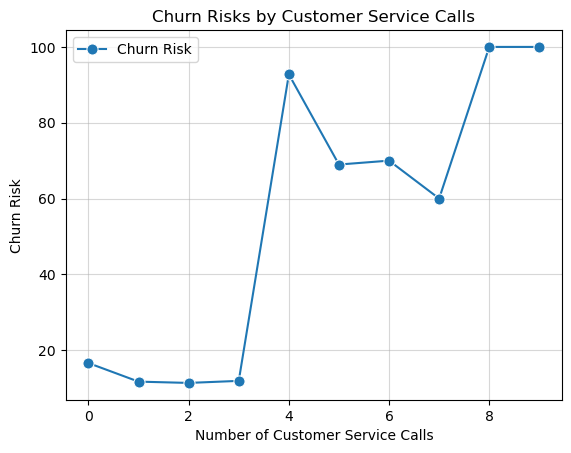

In [29]:
def get_churn_risk(df):
	churn_risks = []
	for n_service_calls in range(0, 11):
		df_new = df.loc[df['customer_service_calls'] == n_service_calls, 'churn']
		churn_risk = (df_new.value_counts() / df_new.shape[0] * 100).values
		if len(churn_risk) == 2:
			churn_risk = churn_risk[1] / churn_risk[0] * 100
			churn_risks.append(round(churn_risk, 2))
		elif len(churn_risk) == 1:
			if churn_risk[0] == False:
				churn_risks.append(0)
			else:
				churn_risks.append(100)

	return churn_risks

churn_risks = get_churn_risk(df)
sns.lineplot(
	y=churn_risks,
	x=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
	marker='o',
	markersize=8,
	linestyle='-',
	label='Churn Risk',	
)
plt.title('Churn Risks by Customer Service Calls')
plt.xlabel('Number of Customer Service Calls')
plt.ylabel('Churn Risk')
plt.grid(True, linestyle='-', alpha=0.5)
plt.legend()
plt.show()

There is no meaningful difference in Customer account length between the churned customers and the non-churned customers.

In [42]:
def get_account_length_info(df: pd.DataFrame) -> None:
	""" Get account length info by churn status

	:param df: DataFrame
	:return: None
	"""
	df_churned = get_churned_customers(df)['account_length']
	df_not_churned = get_stayed_customers(df)['account_length']

	mean_churned = df_churned.mean()
	std_churned = df_churned.std()
	mean_not_churned = df_not_churned.mean()
	std_not_churned = df_not_churned.std()
	
	print(f"Account length for churned customers: {mean_churned:.2f} +/- {std_churned:.2f}")
	print(f"Account length for stayed customers: {mean_not_churned:.2f} +/- {std_not_churned:.2f}")

get_account_length_info(df)

Account length for churned customers: 102.32 +/- 40.18
Account length for stayed customers: 100.33 +/- 39.46


## Products & services
1. Do customers with an international plan churn at a different rate than customers without one?
2. Does having a voicemail plan associate with different churn behavior?
3. Are customers with high voicemail usage different from low/no voicemail users in terms of churn?

In [46]:
def get_customers_with_intl_plan(df):
    return df[df['international_plan'] == "yes"]

def get_customers_with_no_intl_plan(df):
    return df[df['international_plan'] == "no"]

def get_customers_with_voice_mail_plan(df):
    return df[df['voice_mail_plan'] == "yes"]

def get_customers_with_no_voice_mail_plan(df):
    return df[df['voice_mail_plan'] == "no"]

In [64]:
def get_churn_risk_by_intl_plan(df):
    df_intl = get_customers_with_intl_plan(df)
    df_no_intl = get_customers_with_no_intl_plan(df)

	# calculate churn rates
    churn_rate_intl = (df_intl['churn'].value_counts() / df_intl.shape[0] * 100).values.tolist()
    churn_rate_no_intl = (df_no_intl['churn'].value_counts() / df_no_intl.shape[0] * 100).values.tolist()
    
    churn_rate_intl = churn_rate_intl[1] / churn_rate_intl[0] * 100
    churn_rate_no_intl = churn_rate_no_intl[1] / churn_rate_no_intl[0] * 100
    
    print(f"Churn rate with international plan: {churn_rate_intl:.2f}%")
    print(f"Churn rate without international plan: {churn_rate_no_intl:.2f}%")

get_churn_risk_by_intl_plan(df)

Churn rate with international plan: 77.63%
Churn rate without international plan: 12.70%
